In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# 1. Setup Device and Model (Open Box Access)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(device).eval()

In [2]:
# 2. Helper Functions for C&W Math
def arctanh(x):
    # Clamp to avoid infinity in log
    return 0.5 * torch.log((1 + x) / (1 - x))

In [3]:
def cw_l2_attack(model, image, target_class, c, lr, iterations=500):
    """
    Performs the Carlini & Wagner L2 Targeted Attack.
    Optimizes a perturbation to make 'image' classify as 'target_class'.
    """
    # Change of variables to handle box constraints [0, 1] internally
    img_tanh = arctanh((image * 2 - 1) * 0.999999)
    w = nn.Parameter(img_tanh.to(device))
    
    optimizer = optim.Adam([w], lr=lr)
    
    print(f"Starting optimization for target class {target_class}...")
    
    for i in range(iterations):
        optimizer.zero_grad()
        
        # Map back to image space: [0, 1]
        adv_image = 0.5 * (torch.tanh(w) + 1)
        
        # Loss 1: L2 Distortion (keep it looking like a dog)
        l2_dist = torch.sum((adv_image - image)**2)
        
        # Loss 2: Logit-based objective (force it to be a pumpkin)
        outputs = model(adv_image)
        target_logit = outputs[0, target_class]
        other_logits = torch.cat([outputs[0, :target_class], outputs[0, target_class+1:]])
        max_other_logit = torch.max(other_logits)
        
        # f(x) = max(max_{i!=t} Z(x)_i - Z(x)_t, 0)
        loss_f = torch.clamp(max_other_logit - target_logit, min=0.0)
        
        total_loss = l2_dist + c * loss_f
        total_loss.backward()
        optimizer.step()
        
        if i % 100 == 0:
            print(f"Iteration {i}: Total Loss {total_loss.item():.4f}, L2 {l2_dist.item():.4f}")
            
    return 0.5 * (torch.tanh(w).detach() + 1)

Starting optimization for target class 607...
Iteration 0: Total Loss 169.1750, L2 0.0000
Iteration 100: Total Loss 8.9151, L2 8.9151
Iteration 200: Total Loss 11.0568, L2 11.0568
Iteration 300: Total Loss 6.1782, L2 6.1782
Iteration 400: Total Loss 11.6195, L2 11.6195
Iteration 500: Total Loss 12.3779, L2 12.3779
Iteration 600: Total Loss 17.2185, L2 17.2185
Iteration 700: Total Loss 8.6485, L2 8.6485
Iteration 800: Total Loss 14.4846, L2 14.4846
Iteration 900: Total Loss 13.6306, L2 13.6306

Original Prediction ID: 222
Adversarial Prediction ID: 607 (Target: 607)


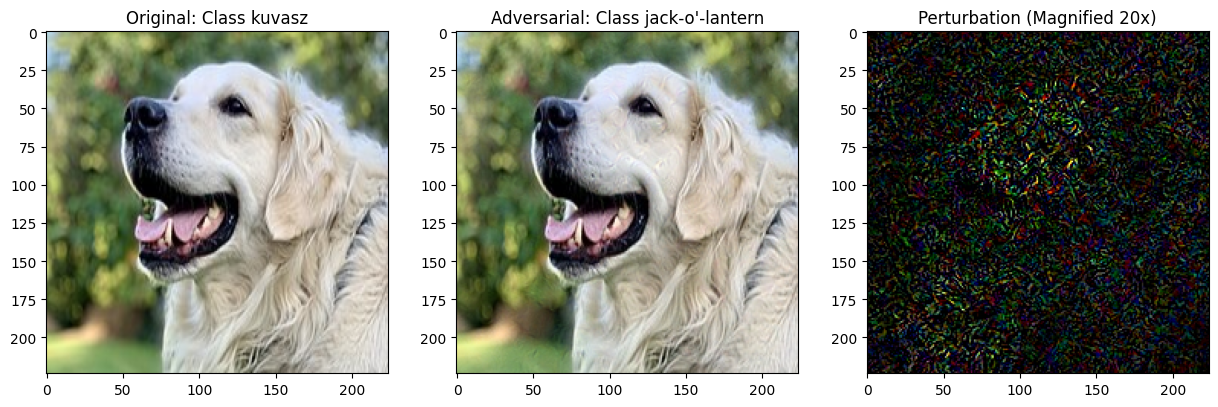

In [7]:
# 3. Data Preparation
# Fetch a dog image (ImageNet Class 248: Eskimo Dog)
url = "Golden_Retriever_2019.jpg"
local_path = "Golden_Retriever_2019.jpg"

img = Image.open(local_path).convert('RGB')

# Standard ImageNet Preprocessing
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
dog_tensor = preprocess(img).unsqueeze(0).to(device)

dog_tensor = preprocess(img).unsqueeze(0).to(device)

# 4. Execute Attack
target_class = 607
adversarial_dog = cw_l2_attack(model, dog_tensor, target_class, c=10.0, lr=0.01, iterations=1000)

# 5. Verification & Visualization
with torch.no_grad():
    orig_pred = torch.argmax(model(dog_tensor)).item()
    adv_pred = torch.argmax(model(adversarial_dog)).item()

print(f"\nOriginal Prediction ID: {orig_pred}")
print(f"Adversarial Prediction ID: {adv_pred} (Target: {target_class})")

# Plotting the results
orig_np = dog_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
adv_np = adversarial_dog.squeeze().cpu().numpy().transpose(1, 2, 0)
diff_np = (adv_np - orig_np)
weights = models.ResNet18_Weights.IMAGENET1K_V1
# Get human-readable labels from weights metadata
orig_name = weights.meta["categories"][orig_pred]
adv_name = weights.meta["categories"][adv_pred]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title(f"Original: Class {orig_name}")
plt.imshow(orig_np)

plt.subplot(1, 3, 2)
plt.title(f"Adversarial: Class {adv_name}")
plt.imshow(adv_np)

plt.subplot(1, 3, 3)
plt.title("Perturbation (Magnified 20x)")
plt.imshow(torch.clamp(torch.tensor(diff_np * 20), 0, 1))
plt.show()